# Empirical Project: Age and Market Value in Professional Football

## Research Question
What is the relationship between a professional football player's age and their market value?

## Motivation
Market value is a key indicator of a football player's performance and potential. Age plays an important role, as younger players may have higher future potential, while older players may benefit from experience. This project aims to analyze how age is related to market value using real-world data.

## Import Libraries

In this section, the required Python libraries for data analysis, visualization, and econometric modeling are imported.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Load Data

The datasets used in this analysis are loaded. The `players` dataset contains player-specific information such as birth date, while the `player_valuations` dataset includes market value data.

In [5]:
players = pd.read_csv("Football_data/players.csv")
valuations = pd.read_csv("Football_data/player_valuations.csv")

## Data Overview

This section provides an initial overview of the datasets. The first rows and column names are displayed to understand the structure of the data.

In [6]:
print(players.head())
print(players.columns)

print(valuations.head())
print(valuations.columns)

   player_id first_name     last_name                name  last_season  \
0         10   Miroslav         Klose      Miroslav Klose         2015   
1         26      Roman  Weidenfeller  Roman Weidenfeller         2017   
2         65    Dimitar      Berbatov    Dimitar Berbatov         2015   
3         77        NaN         Lúcio               Lúcio         2012   
4         80        Tom        Starke          Tom Starke         2017   

   current_club_id         player_code    country_of_birth city_of_birth  \
0              398      miroslav-klose              Poland         Opole   
1               16  roman-weidenfeller             Germany          Diez   
2             1091    dimitar-berbatov            Bulgaria   Blagoevgrad   
3              506               lucio              Brazil      Brasília   
4               27          tom-starke  East Germany (GDR)       Freital   

  country_of_citizenship  ...            agent_name  \
0                Germany  ...  ASBW Sport M

## Data Preparation

In this step, the data is cleaned and prepared for analysis. This includes handling missing values, converting data types, and selecting relevant variables.

In [7]:
# Relevante Spalten auswählen
players_clean = players[[
    "player_id",
    "name",
    "date_of_birth",
    "position",
    "sub_position",
    "current_club_name",
    "market_value_in_eur",
    "highest_market_value_in_eur"
]].copy()

valuations_clean = valuations[[
    "player_id",
    "date",
    "market_value_in_eur"
]].copy()

# Datumsvariablen umwandeln
players_clean["date_of_birth"] = pd.to_datetime(players_clean["date_of_birth"], errors="coerce")
valuations_clean["date"] = pd.to_datetime(valuations_clean["date"], errors="coerce")

# Fehlende Werte prüfen
print("Missing values in players_clean:")
print(players_clean.isna().sum())

print("\nMissing values in valuations_clean:")
print(valuations_clean.isna().sum())

Missing values in players_clean:
player_id                         0
name                              0
date_of_birth                    49
position                          0
sub_position                    455
current_club_name              2713
market_value_in_eur            8476
highest_market_value_in_eur    8476
dtype: int64

Missing values in valuations_clean:
player_id              0
date                   0
market_value_in_eur    0
dtype: int64


## Construct Age Variable

The age of each player is calculated based on their date of birth and the corresponding valuation date. This variable will be the main explanatory variable in the analysis.

In [11]:
# Alter zum Zeitpunkt der Bewertung berechnen
valuations_with_birth = valuations_clean.merge(
    players_clean[["player_id", "date_of_birth"]],
    on="player_id",
    how="left"
)

valuations_with_birth["age"] = (
    (valuations_with_birth["date"] - valuations_with_birth["date_of_birth"]).dt.days / 365.25
)

# Erste Kontrolle
print(valuations_with_birth[["player_id", "date", "date_of_birth", "age"]].head())

   player_id       date date_of_birth        age
0     405973 2000-01-20    1998-01-16   2.009582
1     342216 2001-07-20    1998-02-13   3.430527
2       3132 2003-12-09    1980-03-10  23.748118
3       6893 2003-12-15    1983-11-09  20.098563
4         10 2004-10-04    1978-06-09  26.321697


## Merge Datasets

The player dataset and the valuation dataset are merged using a common identifier. This allows us to combine player characteristics with their market values.

In [12]:
# Letzten verfügbaren Marktwert pro Spieler nehmen
valuations_latest = valuations_with_birth.sort_values("date").groupby("player_id").tail(1)

# Mit weiteren Spielerdaten mergen
df = valuations_latest.merge(
    players_clean.drop(columns=["date_of_birth"]),
    on="player_id",
    how="left"
)

# Spalten umbenennen für Übersicht
df = df.rename(columns={
    "market_value_in_eur_x": "market_value",
    "market_value_in_eur_y": "current_market_value_players_file"
})

print(df.head())
print(df.shape)

   player_id       date  market_value date_of_birth        age  \
0      16733 2005-12-02        100000    1976-06-17  29.459274   
1      73096 2008-04-16         50000    1987-09-10  20.599589   
2      62553 2009-10-25        200000    1990-04-09  19.545517   
3     134354 2009-12-28         50000    1995-01-30  14.910335   
4     144619 2010-03-15         25000    1992-02-22  18.058864   

                name    position    sub_position          current_club_name  \
0         Lee Baxter  Goalkeeper      Goalkeeper  Aarhus Gymnastik Forening   
1                Kim    Defender       Left-Back  Clube Desportivo Nacional   
2       Kurtis Byrne      Attack  Centre-Forward             Ross County FC   
3    Ian Raeymaekers      Attack  Centre-Forward       KSC Lokeren (- 2020)   
4  Sergey Chernyshuk  Goalkeeper      Goalkeeper          FK Spartak Moskva   

   current_market_value_players_file  highest_market_value_in_eur  
0                           100000.0                     100

## Final Sample Restrictions

Observations with missing or implausible values are removed. The final sample includes only players with valid information on age and market value.

In [13]:
# Nur Beobachtungen mit gültigem Alter und Marktwert behalten
df = df.dropna(subset=["age", "market_value"])

# Nur positive Marktwerte
df = df[df["market_value"] > 0]

# Plausiblen Altersbereich setzen
df = df[(df["age"] >= 15) & (df["age"] <= 45)]

# Kontrollausgabe
print(df[["name", "age", "market_value", "position"]].head())
print("\nFinal sample size:", len(df))

                name        age  market_value    position
0         Lee Baxter  29.459274        100000  Goalkeeper
1                Kim  20.599589         50000    Defender
2       Kurtis Byrne  19.545517        200000      Attack
4  Sergey Chernyshuk  18.058864         25000  Goalkeeper
5          Don Cowan  20.361396         50000      Attack

Final sample size: 39190


## Descriptive Statistics

Summary statistics such as mean, median, and standard deviation are computed to provide an overview of the key variables in the dataset.

In [15]:
summary_stats = df[["age", "market_value"]].describe()
print(summary_stats)

summary_table = df[["age", "market_value"]].agg(["mean", "median", "std", "min", "max"])
print(summary_table)

                age  market_value
count  39190.000000  3.919000e+04
mean      27.407638  1.557906e+06
std        5.335657  5.937265e+06
min       15.802875  1.000000e+04
25%       22.941136  1.000000e+05
50%       27.030801  2.750000e+05
75%       31.635866  7.500000e+05
max       43.739904  2.000000e+08
              age  market_value
mean    27.407638  1.557906e+06
median  27.030801  2.750000e+05
std      5.335657  5.937265e+06
min     15.802875  1.000000e+04
max     43.739904  2.000000e+08


## Data Visualization

In this section, graphical methods such as histograms and scatter plots are used to explore the relationship between age and market value.

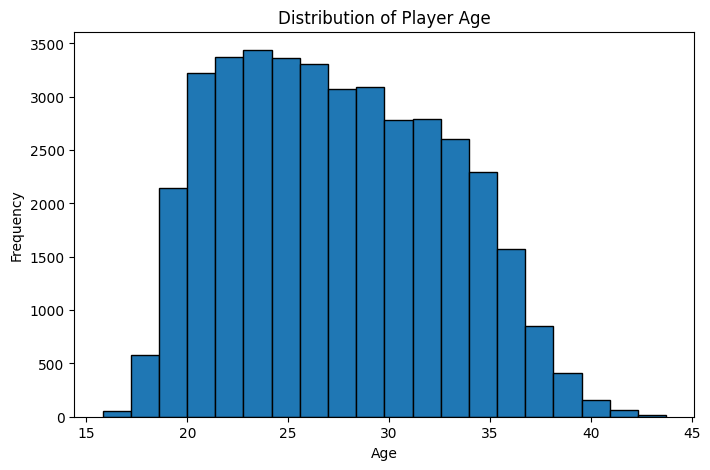

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Player Age")
plt.show()

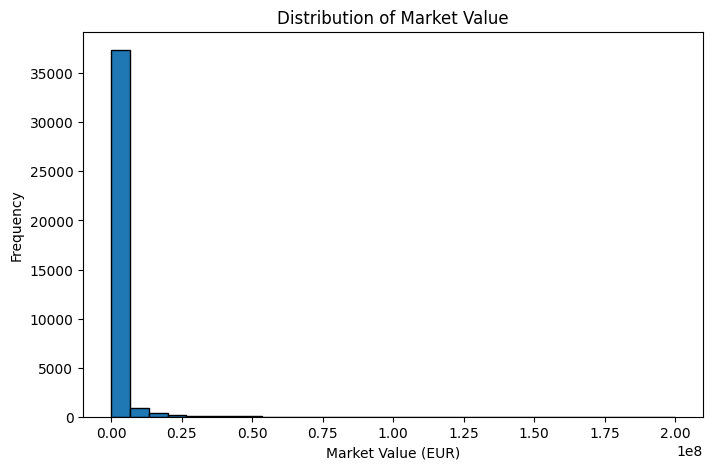

In [19]:
plt.figure(figsize=(8,5))
plt.hist(df["market_value"], bins=30, edgecolor="black")
plt.xlabel("Market Value (EUR)")
plt.ylabel("Frequency")
plt.title("Distribution of Market Value")
plt.show()

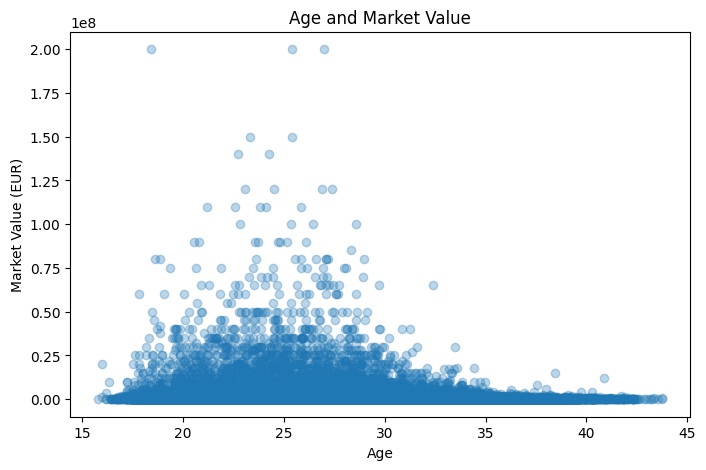

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["market_value"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Market Value (EUR)")
plt.title("Age and Market Value")
plt.show()

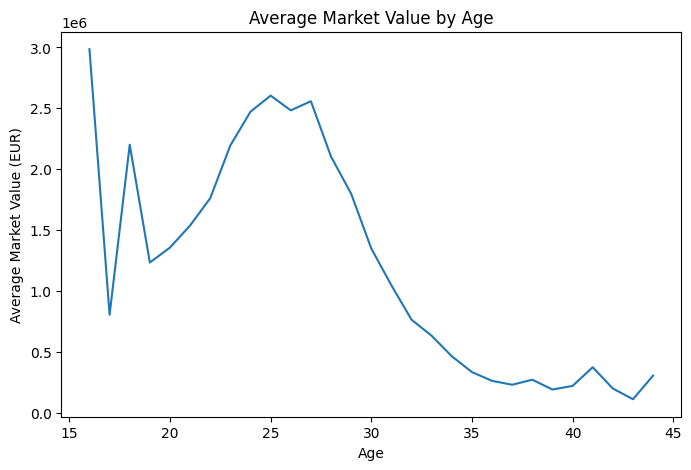

In [20]:
avg_value_by_age = df.groupby(df["age"].round())["market_value"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_value_by_age.index, avg_value_by_age.values)
plt.xlabel("Age")
plt.ylabel("Average Market Value (EUR)")
plt.title("Average Market Value by Age")
plt.show()

## Empirical Method

To analyze the relationship between age and market value, linear regression models are estimated. Both a simple linear model and a model including a quadratic age term are considered.

In [21]:
import statsmodels.formula.api as smf

# Quadratischen Term erstellen
df["age_squared"] = df["age"] ** 2

## Results

The regression results are presented and interpreted. The estimated coefficients indicate how age is related to market value.

In [22]:
model_1 = smf.ols("market_value ~ age", data=df).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:           market_value   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     301.1
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           3.47e-67
Time:                        13:36:12   Log-Likelihood:            -6.6669e+05
No. Observations:               39190   AIC:                         1.333e+06
Df Residuals:                   39188   BIC:                         1.333e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4.221e+06   1.56e+05     26.995      0.0

In [23]:
model_2 = smf.ols("market_value ~ age + age_squared", data=df).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:           market_value   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     247.8
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          1.08e-107
Time:                        13:36:33   Log-Likelihood:            -6.6660e+05
No. Observations:               39190   AIC:                         1.333e+06
Df Residuals:                   39187   BIC:                         1.333e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -6.397e+06    7.8e+05     -8.204      

## Logarithmic Specification

Since market values are highly skewed, an additional model using the logarithm of market value is estimated.

In [24]:
# Logarithmus des Marktwerts
df["log_market_value"] = np.log(df["market_value"])

model_3 = smf.ols("log_market_value ~ age + age_squared", data=df).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:       log_market_value   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     1544.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:37:17   Log-Likelihood:                -70685.
No. Observations:               39190   AIC:                         1.414e+05
Df Residuals:                   39187   BIC:                         1.414e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.1513      0.194     16.231      

## Interpretation

The results are interpreted in the context of the research question. The findings are discussed in terms of economic and practical relevance.

In [25]:
beta_age = model_2.params["age"]
beta_age_sq = model_2.params["age_squared"]

turning_point = -beta_age / (2 * beta_age_sq)
print("Estimated turning point (age at peak market value):", turning_point)

Estimated turning point (age at peak market value): 24.560269117921223


## Limitations



## Conclusion

